# Previsão dos erros (Sawyer, UR10, EDA+PPG)

## Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.utils import resample
import shap

## Carregamento dos dados

In [2]:
# Carregar os dados
dir_dados = "Dados/"
dir_saida = "Saida/"

eda_ppg_df = pd.read_csv(f"{dir_dados}eda_ppg_complete.csv")
eda_ppg_df.describe()

,errors,SCR_Onsets,SCR_Peaks,SCR_Recovery,EDA_Clean_min,EDA_Clean_max,EDA_Clean_median,EDA_Clean_mean,EDA_Clean_std,EDA_Tonic_min,...,HRV_RMSSD_min,HRV_RMSSD_max,HRV_RMSSD_median,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std
count,480.000000,480.00000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,...,476.000000,476.000000,476.000000,476.000000,480.0,476.000000,476.000000,476.000000,476.000000,480.0
mean,1.872917,6.45000,6.535417,6.441667,0.342815,0.626544,0.458433,0.463241,0.057493,0.387335,...,4.864325,4.864325,4.864325,4.864325,0.0,1.377718,1.377718,1.377718,1.377718,0.0
std,3.659075,6.16692,6.173449,6.044782,0.243605,0.257349,0.237157,0.234295,0.039495,0.258845,...,32.993122,32.993122,32.993122,32.993122,0.0,7.597183,7.597183,7.597183,7.597183,0.0
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.034693,0.017564,0.022451,0.002259,0.000000,...,-0.870556,-0.870556,-0.870556,-0.870556,0.0,-0.968235,-0.968235,-0.968235,-0.968235,0.0
25%,0.000000,2.00000,2.000000,2.000000,0.137893,0.434462,0.272836,0.284545,0.030691,0.171087,...,-0.203546,-0.203546,-0.203546,-0.203546,0.0,-0.191731,-0.191731,-0.191731,-0.191731,0.0
50%,0.000000,5.00000,5.000000,5.000000,0.324624,0.637955,0.457067,0.467429,0.048506,0.388596,...,0.184286,0.184286,0.184286,0.184286,0.0,0.108913,0.108913,0.108913,0.108913,0.0
75%,2.000000,10.00000,10.000000,10.000000,0.522561,0.832079,0.642103,0.642294,0.072658,0.584746,...,0.703788,0.703788,0.703788,0.703788,0.0,0.523683,0.523683,0.523683,0.523683,0.0
max,21.000000,62.00000,61.000000,58.000000,0.925814,1.000000,0.964892,0.958303,0.321517,0.957100,...,383.446336,383.446336,383.446336,383.446336,0.0,65.833333,65.833333,65.833333,65.833333,0.0


In [3]:
sawyer_df = pd.read_csv(f"{dir_dados}sawyer_errors.csv")
sawyer_df.drop(['Unnamed: 0'],axis=1,inplace=True)
sawyer_df.describe()

,Subject,errors,Code,Order,HR_BPM,RMSSD,SDNN,pNN50,pNN20,HRV_LFHF,...,EDA_SM_Phasic_Max,EDA_SM_Phasic_Mean,EDA_SM_Phasic_AUC,EDA_SM_Phasic_nPeaks,EDA_SM_SCR_RiseTime,EDA_SM_SCR_Amplitude_Mean,Temp_Mean,Temp_Std,Temp_Slope,Start_min
count,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,...,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000
mean,17.978873,4.359155,9.514085,3.521127,82.533889,167.330888,138.981694,52.577555,76.036275,0.305249,...,0.026890,0.002562,0.102405,19.193662,0.891151,0.006707,-0.002474,0.001017,0.000035,12.311854
std,7.326691,5.559914,1.720696,1.712359,10.242293,120.111117,98.202242,27.430049,14.724600,0.176353,...,0.025249,0.002582,0.103212,9.738759,0.382625,0.006309,0.043607,0.000936,0.000110,8.142315
min,6.000000,0.000000,7.000000,1.000000,56.013991,24.169061,19.454146,1.851852,43.181818,0.028533,...,0.000296,0.000031,0.001259,6.000000,0.300099,0.000078,-0.206166,0.000041,-0.000176,0.200000
25%,12.000000,0.000000,8.000000,2.000000,75.164799,60.206642,50.893887,30.395299,64.500676,0.194992,...,0.007821,0.000637,0.025400,12.000000,0.563885,0.001596,-0.011383,0.000389,-0.000029,5.141833
50%,17.500000,2.000000,10.000000,4.000000,82.221708,134.150047,106.541538,57.275132,79.167256,0.267446,...,0.017193,0.001878,0.075068,16.500000,0.813317,0.005207,0.003445,0.000687,0.000008,13.446001
75%,24.000000,6.000000,11.000000,5.000000,88.773535,276.987962,225.732130,78.638340,89.482822,0.372661,...,0.042322,0.003707,0.148091,23.000000,1.171094,0.009480,0.013415,0.001337,0.000087,19.049181
max,30.000000,21.000000,12.000000,6.000000,112.359962,442.981664,354.988112,95.454545,100.000000,1.049623,...,0.101315,0.016167,0.646382,63.000000,2.066964,0.034361,0.102471,0.005794,0.000501,26.422499


In [4]:
ur10_df = pd.read_csv(f"{dir_dados}ur10_errors.csv")
ur10_df.drop(['Unnamed: 0'],axis=1,inplace=True)
ur10_df.describe()

,Subject,errors,Code,Order,HR_BPM,RMSSD,SDNN,pNN50,pNN20,HRV_LF,...,EDA_SM_Phasic_Max,EDA_SM_Phasic_Mean,EDA_SM_Phasic_AUC,EDA_SM_Phasic_nPeaks,EDA_SM_SCR_RiseTime,EDA_SM_SCR_Amplitude_Mean,Temp_Mean,Temp_Std,Temp_Slope,Start_min
count,368.000000,333.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,...,356.000000,356.000000,356.000000,356.000000,356.000000,356.000000,368.000000,368.000000,368.000000,368.000000
mean,118.019022,0.816817,6.480978,6.342391,80.173418,118.062649,99.615187,43.326019,70.587816,0.016406,...,0.022691,0.002069,0.082704,18.544944,1.061951,0.006523,-0.004509,0.000791,0.000003,22.332924
std,9.950404,1.506838,3.453019,3.424093,12.269876,95.332452,70.005607,24.142563,12.803050,0.005807,...,0.028130,0.002740,0.109538,14.092080,0.605238,0.009138,0.072388,0.001203,0.000093,13.033759
min,101.000000,0.000000,1.000000,1.000000,51.004525,25.803417,23.341000,1.408451,42.622951,0.002479,...,0.000217,0.000021,0.000836,3.000000,0.255682,0.000059,-0.214622,0.000025,-0.000243,0.000000
25%,109.000000,0.000000,3.000000,3.000000,74.733702,46.101358,48.976358,23.179945,60.920516,0.012466,...,0.004891,0.000334,0.013378,9.000000,0.609434,0.000833,-0.026413,0.000281,-0.000048,11.557886
50%,119.000000,0.000000,6.500000,6.000000,79.549279,75.598487,73.261562,38.864241,68.750000,0.016735,...,0.012405,0.000953,0.038117,14.000000,0.881189,0.002796,-0.005119,0.000546,-0.000008,22.166146
75%,127.000000,1.000000,9.000000,9.000000,86.838618,167.904147,130.191882,64.285714,80.940585,0.020990,...,0.029660,0.002557,0.102035,24.000000,1.382487,0.008193,0.013009,0.000903,0.000036,33.430582
max,134.000000,8.000000,12.000000,12.000000,119.775561,408.196366,368.113437,92.682927,97.619048,0.031024,...,0.252780,0.015275,0.610331,77.000000,3.343750,0.060304,0.362911,0.012922,0.000594,51.392138


## Análise EDA+PPG

In [5]:
def msno_cols(df):
    missing_cols = []
    if df.isna().sum().sum() != 0:
        print("Missing values found...\n")
        for col in df.columns:
            if df[col].isna().sum() > 0:
                missing_cols.append(col)
    else:
        print("No missing values found...\n")
    print(missing_cols)
    return missing_cols

missing_cols = msno_cols(eda_ppg_df)

Missing values found...

['SCR_Height_min', 'SCR_Height_max', 'SCR_Height_median', 'SCR_Height_mean', 'SCR_Height_std', 'SCR_Amplitude_min', 'SCR_Amplitude_max', 'SCR_Amplitude_median', 'SCR_Amplitude_mean', 'SCR_Amplitude_std', 'SCR_RiseTime_min', 'SCR_RiseTime_max', 'SCR_RiseTime_median', 'SCR_RiseTime_mean', 'SCR_RiseTime_std', 'HRV_MeanNN_min', 'HRV_MeanNN_max', 'HRV_MeanNN_median', 'HRV_MeanNN_mean', 'HRV_MedianNN_min', 'HRV_MedianNN_max', 'HRV_MedianNN_median', 'HRV_MedianNN_mean', 'HRV_SDNN_min', 'HRV_SDNN_max', 'HRV_SDNN_median', 'HRV_SDNN_mean', 'HRV_RMSSD_min', 'HRV_RMSSD_max', 'HRV_RMSSD_median', 'HRV_RMSSD_mean', 'HRV_pNN50_min', 'HRV_pNN50_max', 'HRV_pNN50_median', 'HRV_pNN50_mean']


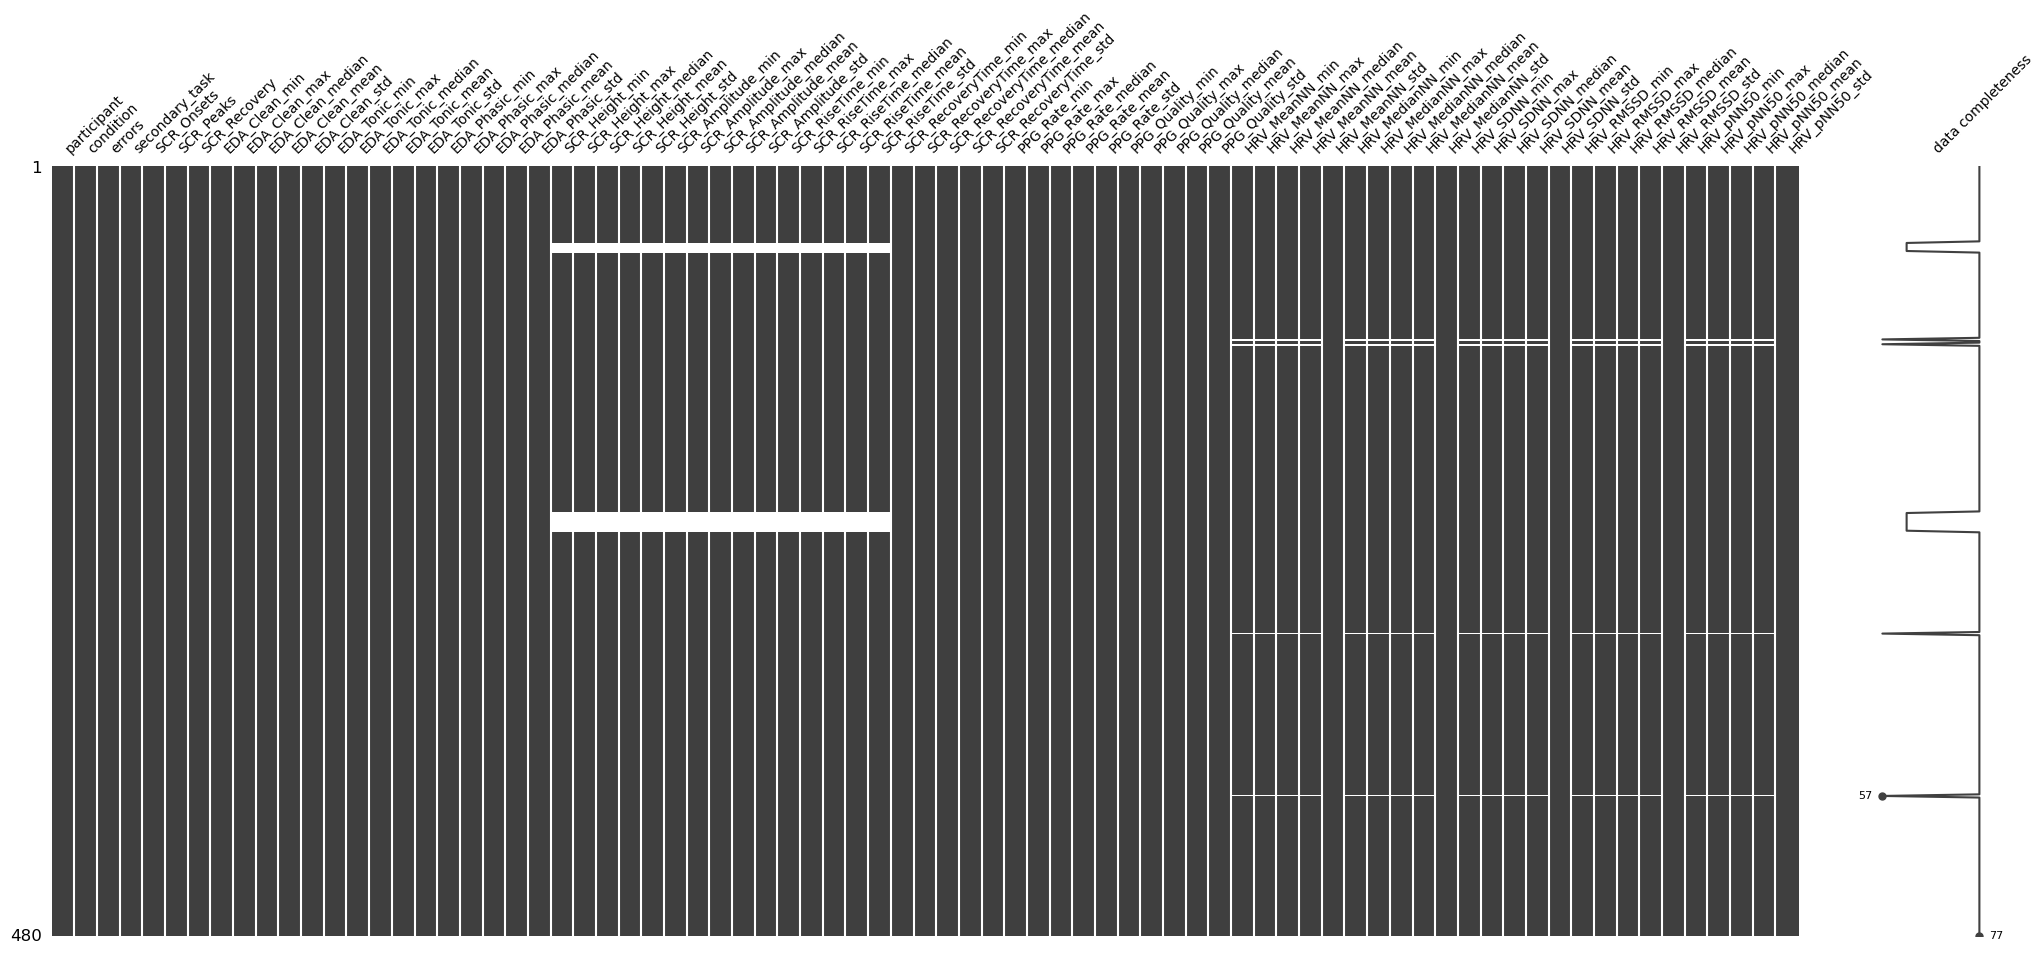

In [6]:
# Gráfico para ilustrar os valores em falta do dataset EDA+PPG
msno.matrix(eda_ppg_df, fontsize=10, labels=True)
plt.savefig(f"{dir_saida}EDA_PPG_Missing_Values_MSNO.png", bbox_inches='tight', dpi=300)

In [7]:
# Quais sujeitos têm valores em falta?
def missing_subjects(df):
    return df[df.isnull().any(axis=1)]['participant'].unique()

null_subjects = missing_subjects(eda_ppg_df)
print(null_subjects)

<ArrowStringArray>
['S14', 'S25', 'S108', 'S115', 'S125']
Length: 5, dtype: str


In [8]:
# Imputar valores em falta com KNNImputer
eda_ppg_clean_df = eda_ppg_df.copy()
print("Valores em falta antes da imputação:", eda_ppg_clean_df[missing_cols].isna().sum().sum())

imp = KNNImputer(n_neighbors=5)
eda_ppg_clean_df[missing_cols] = imp.fit_transform(eda_ppg_clean_df[missing_cols])

print("Valores em falta depois da imputação:", eda_ppg_clean_df[missing_cols].isna().sum().sum())

Valores em falta antes da imputação: 350
Valores em falta depois da imputação: 0


In [9]:
print("'SCR_Amplitude_median' unique values:" ,eda_ppg_clean_df["SCR_Amplitude_median"].unique())
print("'SCR_Amplitude_min' unique values:" ,eda_ppg_clean_df["SCR_Amplitude_min"].unique())
print("'SCR_RiseTime_median' unique values:" ,eda_ppg_clean_df["SCR_RiseTime_median"].unique())
print("'SCR_RiseTime_min' unique values:" ,eda_ppg_clean_df["SCR_RiseTime_min"].unique())

'SCR_Amplitude_median' unique values: [0.]
'SCR_Amplitude_min' unique values: [0.]
'SCR_RiseTime_median' unique values: [0.]
'SCR_RiseTime_min' unique values: [0.]


In [10]:
to_drop = ["SCR_Amplitude_median",
           "SCR_Amplitude_min",
           "SCR_RiseTime_median",
           "SCR_RiseTime_min"]

eda_ppg_aux = eda_ppg_df.copy()

def drop_cols(df1, df2, lst, cols):
    df1.drop(cols, axis=1, inplace=True)
    df2.drop(cols, axis=1, inplace=True)

    for col in cols:
        lst.remove(col)

drop_cols(eda_ppg_clean_df, eda_ppg_aux, missing_cols, to_drop)

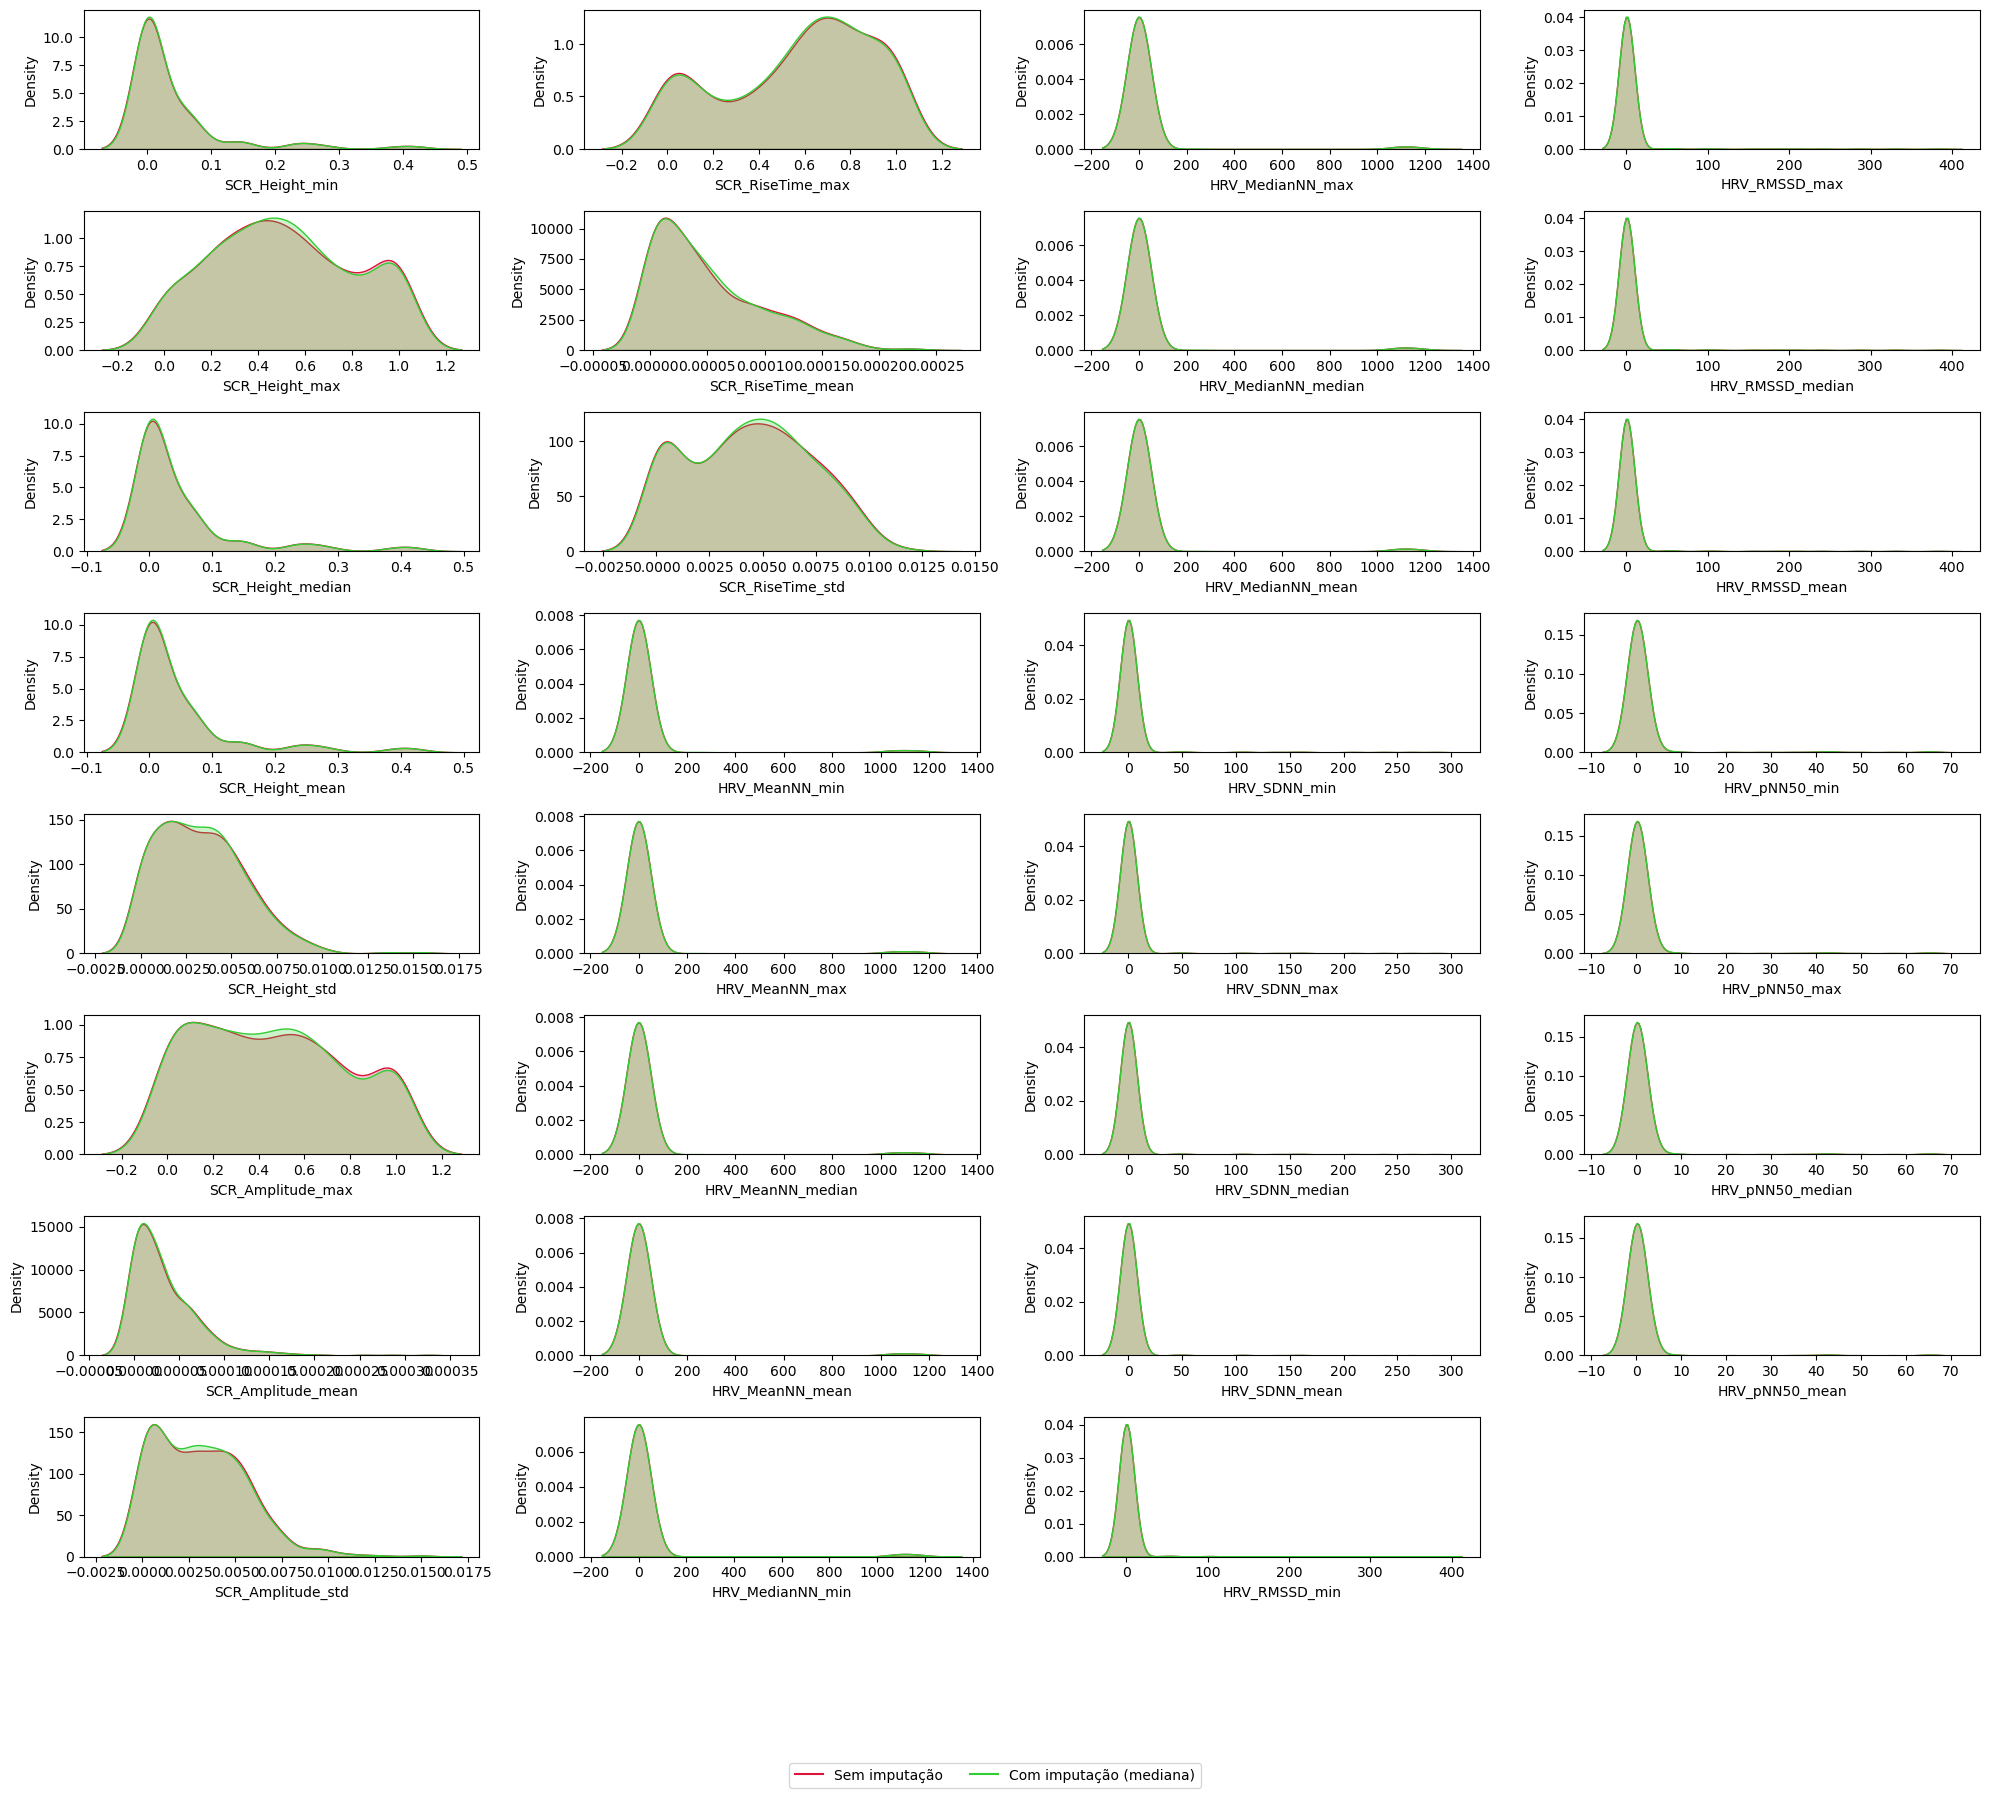

In [11]:
# Compare imputed vs non-imputed distributions.
fig_rows = 8
fig_cols = 4
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(20, 18))

# Create a single legend outside the grid.
legend_elements = [
    plt.Line2D([], [], color='crimson', label='Sem imputação'),
    plt.Line2D([], [], color='limegreen', label='Com imputação (mediana)')
]

# Add the legend to the figure (outside the grid).
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2)

ax1 = 0
ax2 = 0

for col in missing_cols:
    p1 = sns.kdeplot(data=eda_ppg_aux[col], color='crimson', fill=True, ax=axes[ax1, ax2])
    p2 = sns.kdeplot(data=eda_ppg_clean_df[col], color='limegreen', fill=True, ax=axes[ax1, ax2])

    if ax1 < fig_rows-1:
        ax1 = ax1 + 1
    else:
        ax1 = 0
        ax2 = ax2 + 1

# Hide unused subplots.
for i in range(len(missing_cols), fig_rows * fig_cols):
    axes.flatten()[i].axis('off')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust layout to make space for the legend.
plt.savefig(f"{dir_saida}EDA_PPG_Imputed_vs_NonImputed_Distribution.png", bbox_inches='tight', dpi=300)
plt.show()

Como podemos ver na figura acima, as distribuições são muito semelhantes, ou seja, não estamos a modificar significativamente o dataset com a imputação.

## Análise Sawyer

In [12]:
missing_cols = msno_cols(sawyer_df)

No missing values found...

[]


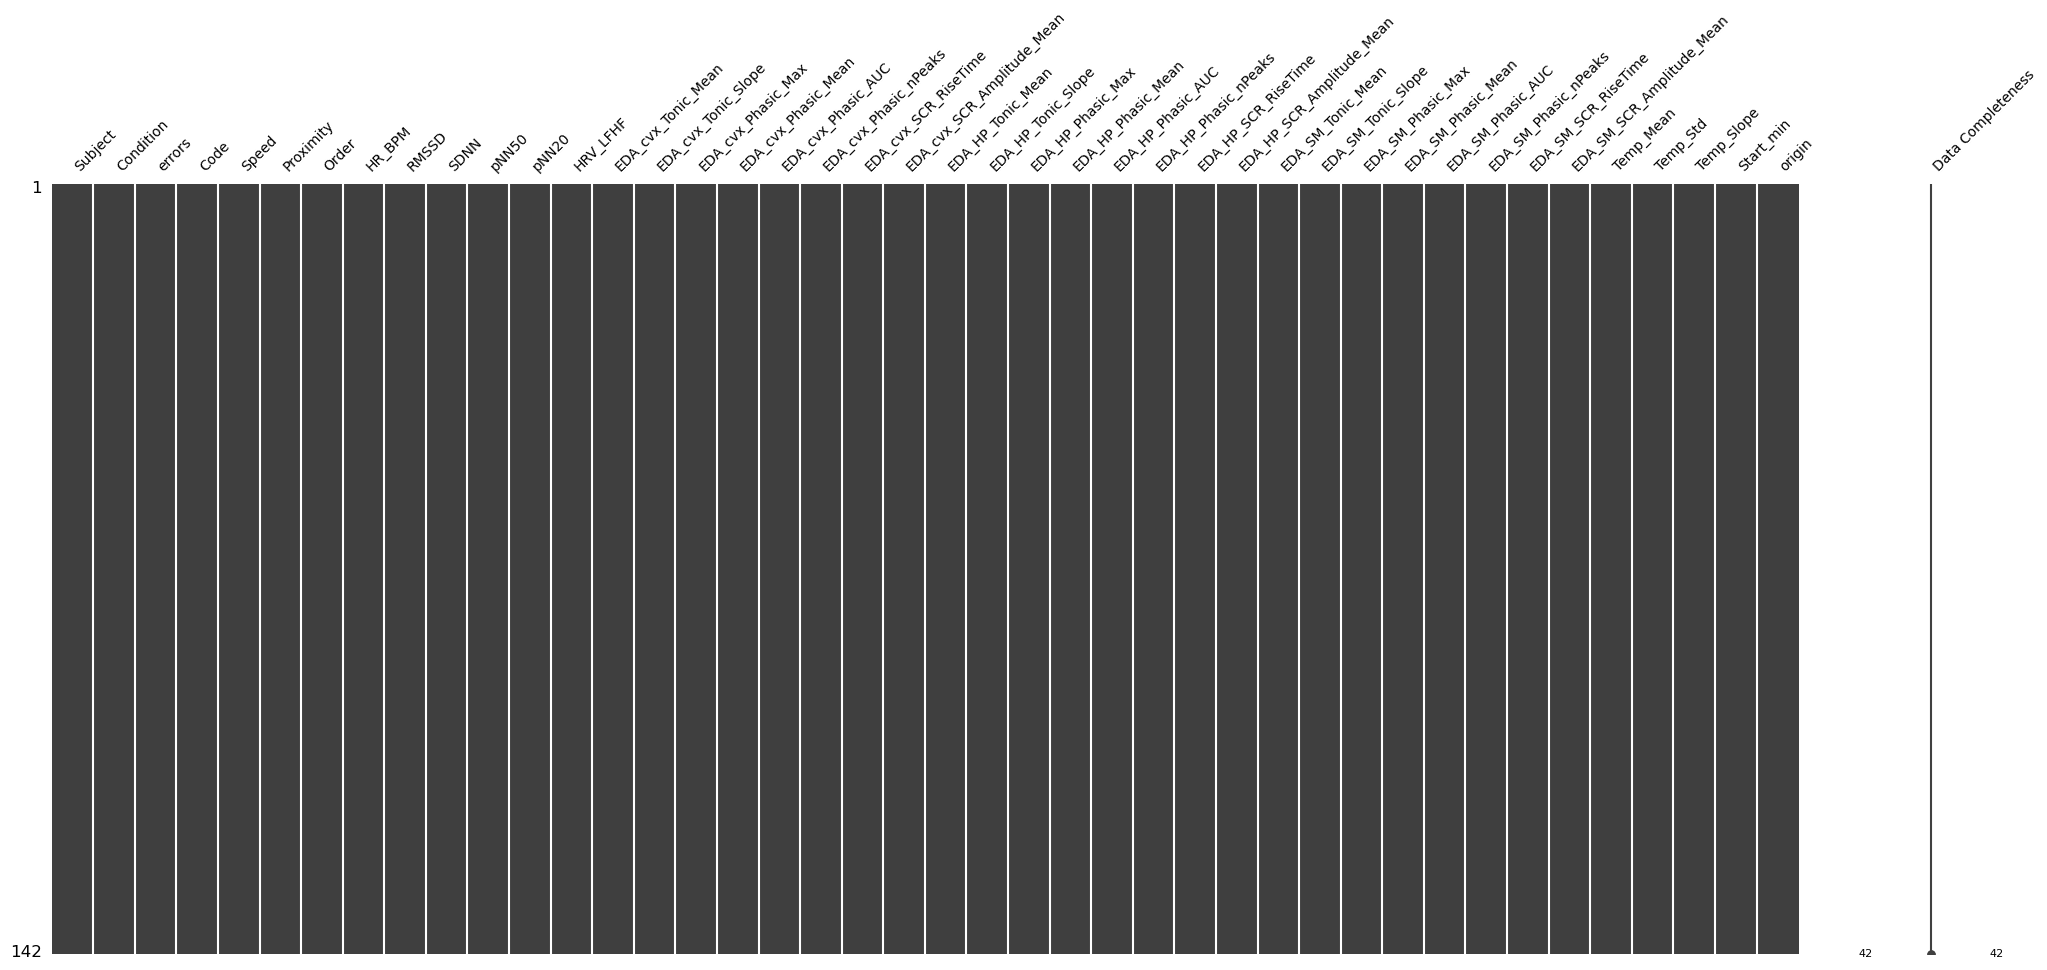

In [13]:
# Gráfico dos valores em falta
msno.matrix(sawyer_df, fontsize=10, labels=True)
plt.savefig(f"{dir_saida}Sawyer_Missing_Values_MSNO.png", bbox_inches='tight', dpi=300)

Os dados sawyer estão completos, ou seja, não precisamos de realizar imputação.

## Análise UR10

In [14]:
missing_cols = msno_cols(ur10_df)

Missing values found...

['errors', 'EDA_cvx_Phasic_nPeaks', 'EDA_cvx_SCR_RiseTime', 'EDA_cvx_SCR_Amplitude_Mean', 'EDA_HP_Tonic_Mean', 'EDA_HP_Tonic_Slope', 'EDA_HP_Phasic_Max', 'EDA_HP_Phasic_Mean', 'EDA_HP_Phasic_AUC', 'EDA_HP_Phasic_nPeaks', 'EDA_HP_SCR_RiseTime', 'EDA_HP_SCR_Amplitude_Mean', 'EDA_SM_Tonic_Mean', 'EDA_SM_Tonic_Slope', 'EDA_SM_Phasic_Max', 'EDA_SM_Phasic_Mean', 'EDA_SM_Phasic_AUC', 'EDA_SM_Phasic_nPeaks', 'EDA_SM_SCR_RiseTime', 'EDA_SM_SCR_Amplitude_Mean']


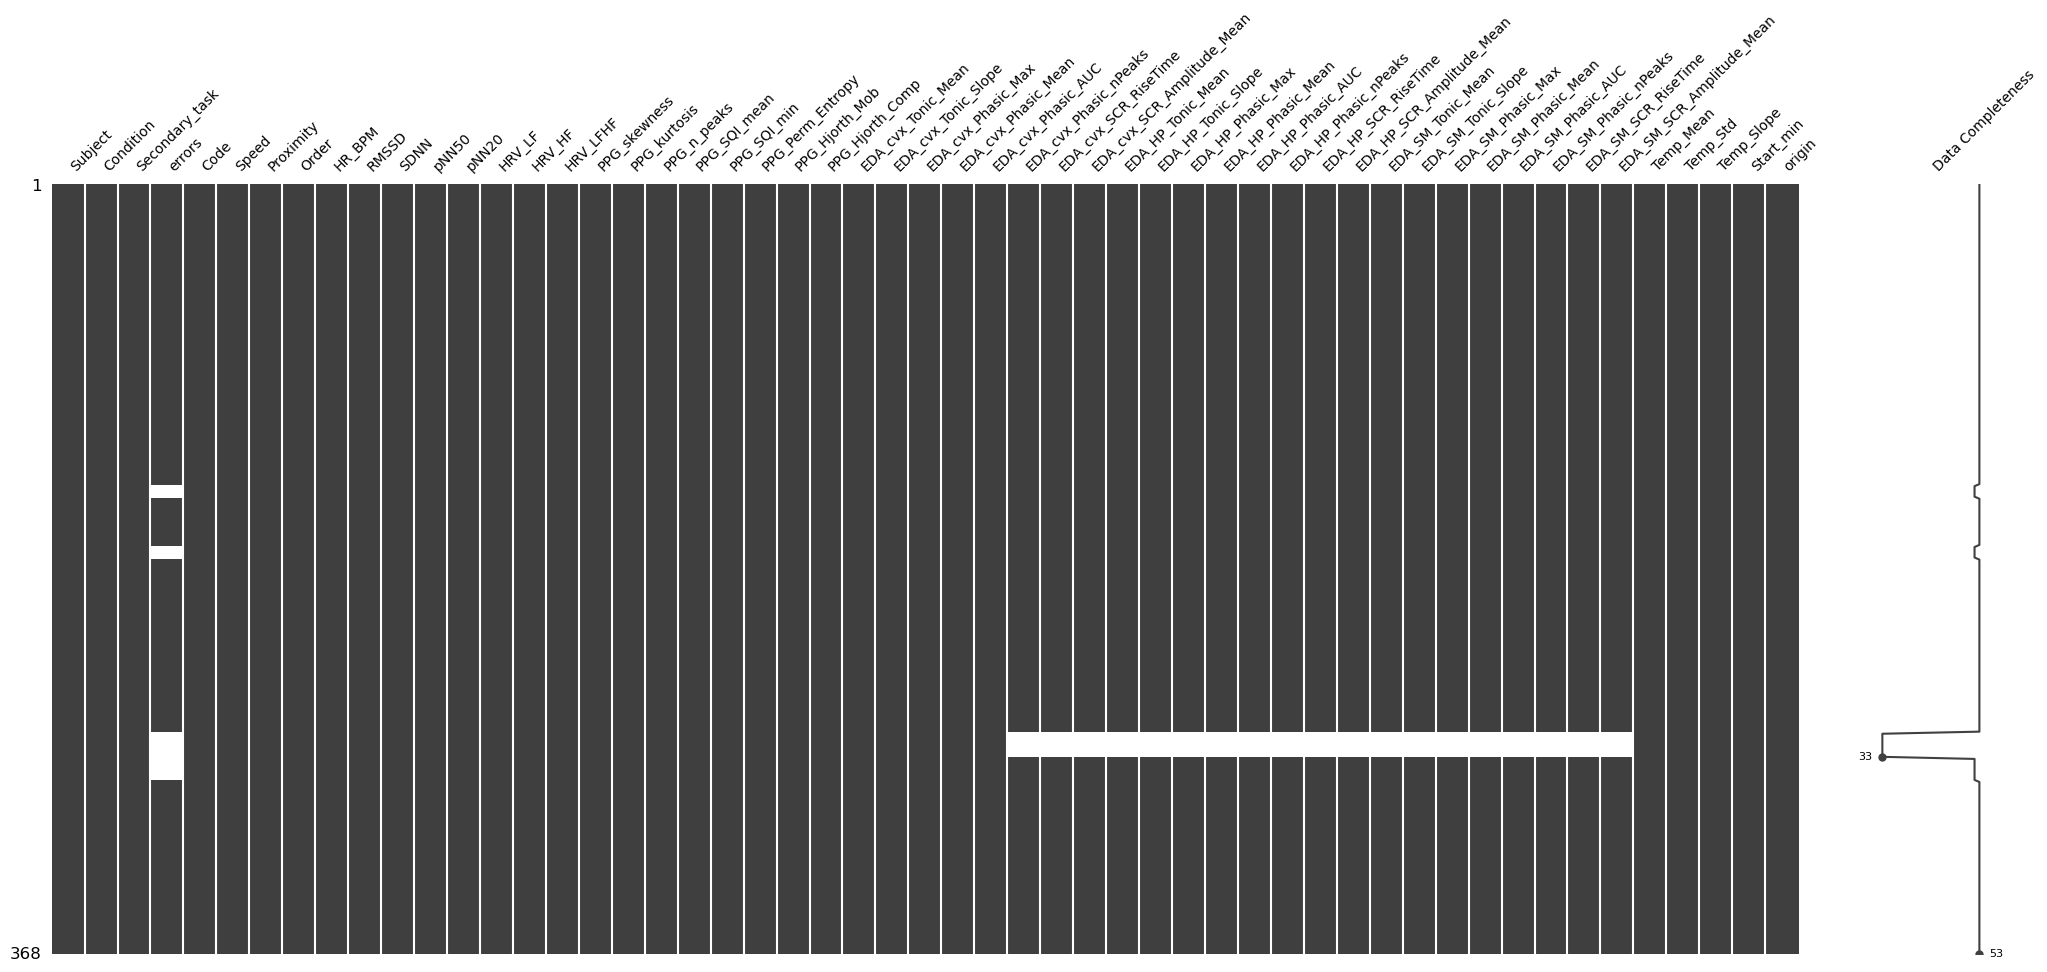

In [15]:
# Gráfico dos valores em falta
msno.matrix(ur10_df, fontsize=10, labels=True)
plt.savefig(f"{dir_saida}UR10_Missing_Values_MSNO.png", bbox_inches='tight', dpi=300)

In [16]:
def missing_subjects(df):
    return df[df.isnull().any(axis=1)]['Subject'].unique()

null_subjects = missing_subjects(ur10_df)
print(null_subjects)

[114 118 126 127]


In [17]:
ur10_fix_df = ur10_df[ur10_df['errors'].notna()]

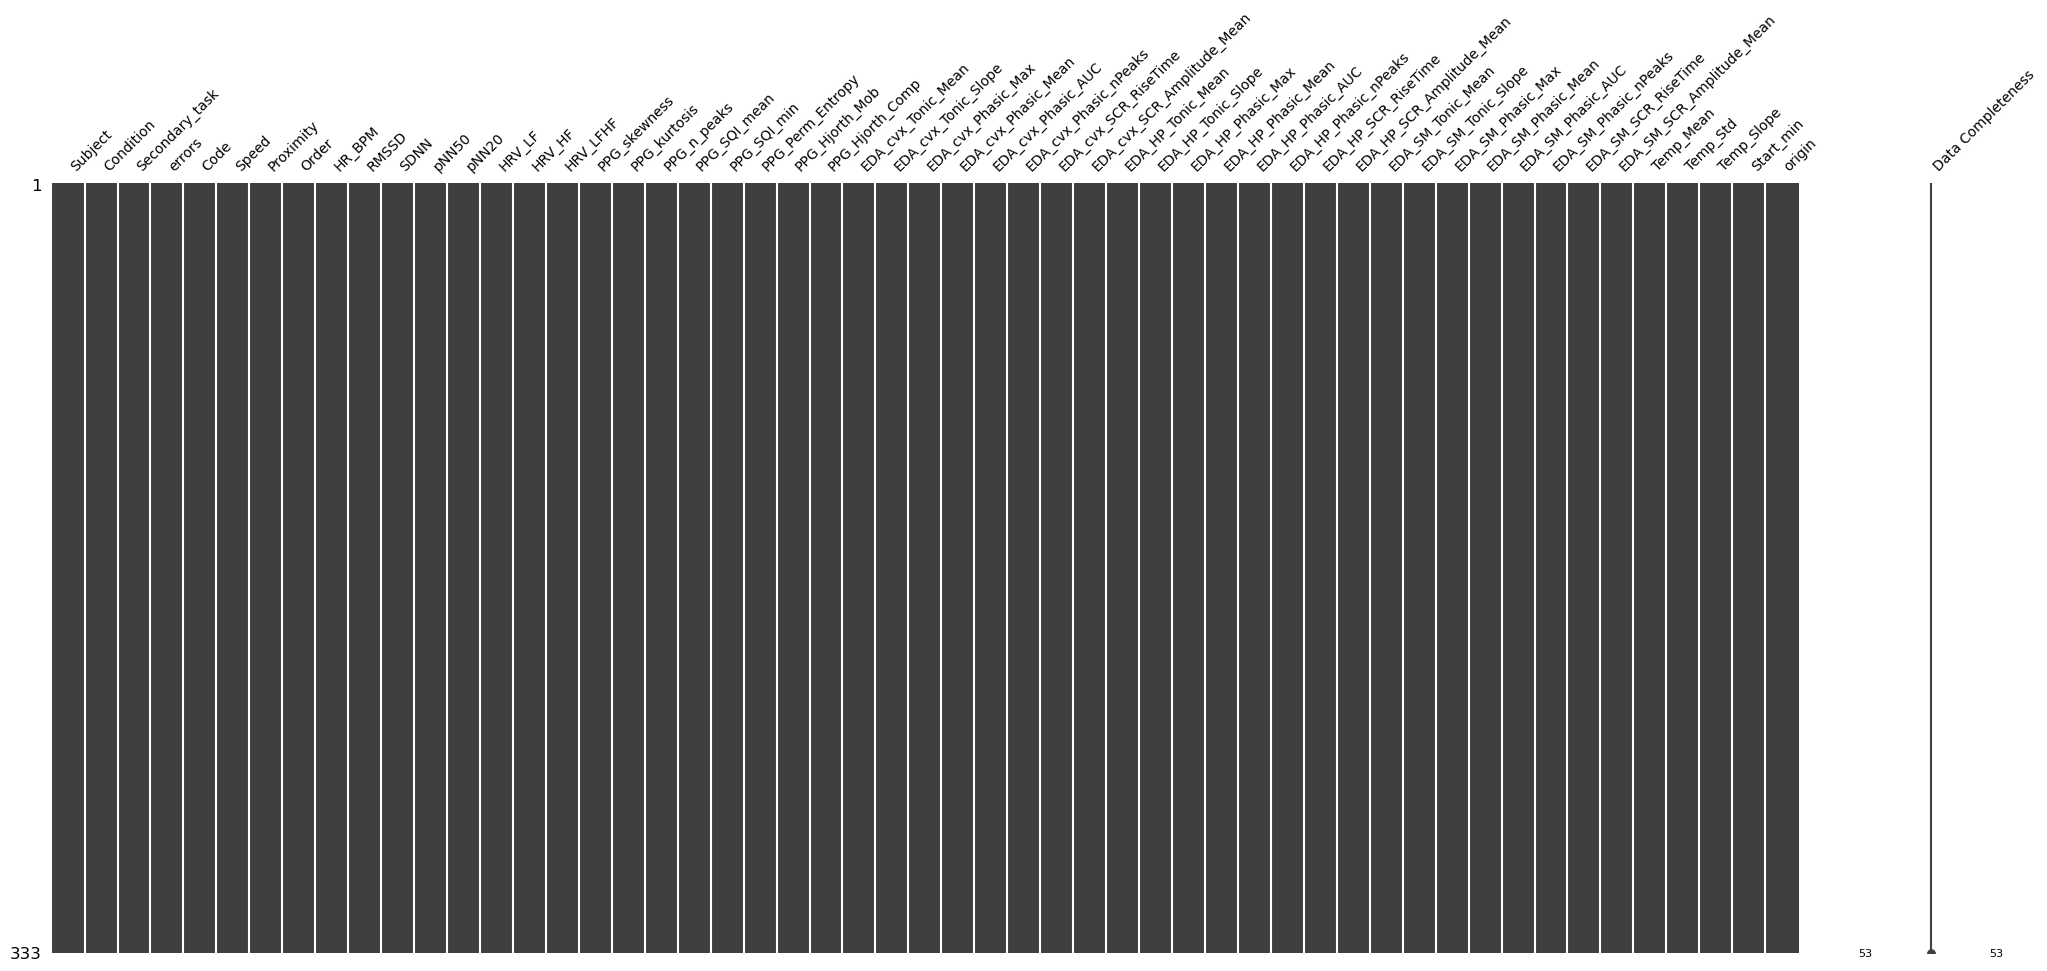

In [18]:
# Gráfico dos valores em falta do ur10 corrigido
msno.matrix(ur10_fix_df, fontsize=10, labels=True)
plt.savefig(f"{dir_saida}UR10_Corrigido_Missing_Values_MSNO.png", bbox_inches='tight', dpi=300)

## Análise Pre-Modelação

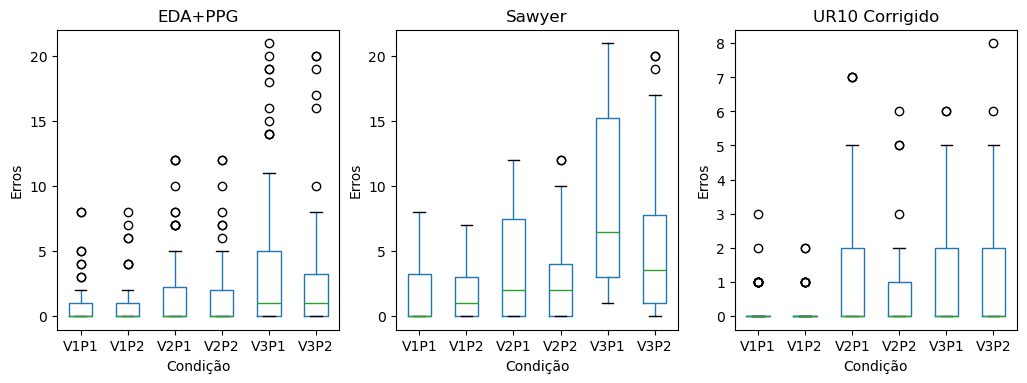

In [19]:
# Compare imputed vs non-imputed distributions.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

ax1 = eda_ppg_clean_df.boxplot(by ='condition', column =['errors'], grid = False, ax=axes[0])
ax1.set_title('EDA+PPG')
ax1.set_xlabel('Condição')
ax1.set_ylabel('Erros')

ax2 = sawyer_df.boxplot(by ='Condition', column =['errors'], grid = False, ax=axes[1])
ax2.set_title('Sawyer')
ax2.set_xlabel('Condição')
ax2.set_ylabel('Erros')

ax3 = ur10_fix_df.boxplot(by ='Condition', column =['errors'], grid = False, ax=axes[2])
ax3.set_title('UR10 Corrigido')
ax3.set_xlabel('Condição')
ax3.set_ylabel('Erros')

fig.suptitle('')
plt.savefig(f"{dir_saida}Boxplot_Errors_Condition.png", bbox_inches='tight', dpi=300)
plt.show()

## Modelação

### Modelação EDA+PPG

In [20]:
def run_pipeline_classification_ternary(df, target="errors", subject_col="participant"):
    df = df.copy()

    speed_dict = {'V1P1': 'V1', 'V1P2': 'V1', 'V2P1': 'V2', 'V2P2': 'V2', 'V3P1': 'V3', 'V3P2': 'V3'}
    position_dict = {'V1P1': 'P1', 'V1P2': 'P2', 'V2P1': 'P1', 'V2P2': 'P2', 'V3P1': 'P1', 'V3P2': 'P2'}

    df['speed'] = df['condition'].map(speed_dict)
    df['position'] = df['condition'].map(position_dict)

    df['speed_encoded'] = LabelEncoder().fit_transform(df['speed'])
    df['position_encoded'] = LabelEncoder().fit_transform(df['position'])
    df['secondary_task_encoded'] = LabelEncoder().fit_transform(df['secondary_task'])

    df.drop(columns=['speed', 'position', 'condition', 'secondary_task'], inplace=True)

    bin_edges = [-np.inf, df[target].quantile(0.33), df[target].quantile(0.66), np.inf]
    df["errors_bin"] = pd.cut(df[target], bins=bin_edges, labels=["low", "medium", "high"], duplicates="drop")

    print("\nDistribuição das classes:")
    print(df["errors_bin"].value_counts())

    # Visualização dos erros
    print("\nValores de erros por classe:")
    for classe in ["low", "medium", "high"]:
        sub = df[df["errors_bin"] == classe]
        print(f"\n{classe}:")
        print(f"  Número de amostras: {len(sub)}")
        print(f"  Min: {sub[target].min()}")
        print(f"  Max: {sub[target].max()}")
        print(f"  Média: {sub[target].mean():.3f}")
        print(f"  Mediana: {sub[target].median():.3f}")
        
    y = df["errors_bin"]
    groups = df[subject_col]
    X = df.drop(columns=[target, "errors_bin", subject_col])

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    X = X[numeric_cols]

    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    X_imp = KNNImputer(n_neighbors=5).fit_transform(X)
    rf.fit(X_imp, y)

    importances = pd.DataFrame({
        "feature": numeric_cols,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nAs 15 features mais importantes:")
    print(importances.head(15))

    threshold = importances["importance"].mean()
    selected_features = importances[importances["importance"] > threshold]["feature"].tolist()

    print(f"\n{len(selected_features)} selected features:")
    print(selected_features)

    corr_matrix = pd.DataFrame(X_imp, columns=numeric_cols)[selected_features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

    print(f"\nFeatures redundantes (para remover): {to_drop}")

    final_features = [f for f in selected_features if f not in to_drop]
    print(f"\n{len(final_features)} final features:")
    print(final_features)

    X_final = X[final_features]

    cv = GroupKFold(n_splits=5)

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
    }

    results = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("imputer", KNNImputer(n_neighbors=5)),
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        scores = cross_val_score(pipeline, X_final, y, cv=cv, groups=groups, scoring="accuracy")
        results[name] = {"mean": scores.mean(), "std": scores.std(), "scores": scores}

        print(f"\n{name}:")
        print(f"  Mean Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
        print(f"  Scores per fold: {scores}")

    best_model = max(results, key=lambda x: results[x]["mean"])
    print(f"\nMelhor modelo: {best_model}")
    print(f"Accuracy: {results[best_model]['mean']:.3f} (+/- {results[best_model]['std']:.3f})")

    return results, final_features

In [21]:
eda_ppg_ternary_results = run_pipeline_classification_ternary(eda_ppg_df, target="errors", subject_col="participant")


Distribuição das classes:
errors_bin
low       265
high      145
medium     70
Name: count, dtype: int64

Valores de erros por classe:

low:
  Número de amostras: 265
  Min: 0.0
  Max: 0.0
  Média: 0.000
  Mediana: 0.000

medium:
  Número de amostras: 70
  Min: 1.0
  Max: 1.0
  Média: 1.000
  Mediana: 1.000

high:
  Número de amostras: 145
  Min: 2.0
  Max: 21.0
  Média: 5.717
  Mediana: 4.000

As 15 features mais importantes:
                   feature  importance
75  secondary_task_encoded    0.106614
73           speed_encoded    0.041422
21         SCR_Height_mean    0.036430
19          SCR_Height_max    0.028016
7            EDA_Clean_std    0.025258
3            EDA_Clean_min    0.023847
41           PPG_Rate_mean    0.021056
20       SCR_Height_median    0.020852
27       SCR_Amplitude_std    0.020790
6           EDA_Clean_mean    0.020517
17          EDA_Phasic_std    0.020449
9            EDA_Tonic_max    0.019418
53        HRV_MedianNN_min    0.019064
4            EDA_Clean

In [22]:
def run_pipeline_classification_binary(df, target="errors", subject_col="participant"):
    df = df.copy()

    speed_dict = {'V1P1': 'V1', 'V1P2': 'V1', 'V2P1': 'V2', 'V2P2': 'V2', 'V3P1': 'V3', 'V3P2': 'V3'}
    position_dict = {'V1P1': 'P1', 'V1P2': 'P2', 'V2P1': 'P1', 'V2P2': 'P2', 'V3P1': 'P1', 'V3P2': 'P2'}

    df['speed'] = df['condition'].map(speed_dict)
    df['position'] = df['condition'].map(position_dict)

    df['speed_encoded'] = LabelEncoder().fit_transform(df['speed'])
    df['position_encoded'] = LabelEncoder().fit_transform(df['position'])
    df['secondary_task_encoded'] = LabelEncoder().fit_transform(df['secondary_task'])

    df.drop(columns=['speed', 'position', 'condition', 'secondary_task'], inplace=True)

    # Criar target binário: 0 = Sem erros, 1 = Com erros
    threshold_errors = 0
    df["errors_binary"] = (df[target] > threshold_errors).astype(int)

    # Mapear para labels legíveis
    label_map = {0: "Sem erros", 1: "Com erros"}
    df["errors_class"] = df["errors_binary"].map(label_map)

    print("\nDistribuição das classes:")
    print(df["errors_class"].value_counts())

    proportions = df["errors_binary"].value_counts(normalize=True)
    print(f"Proporção classe 'Sem erros' (0): {proportions.get(0, 0):.3f}")
    print(f"Proporção classe 'Com erros' (1): {proportions.get(1, 0):.3f}")

    # Visualização da binarização dos erros
    threshold_errors = df[target].median()
    df["errors_binary"] = (df[target] > threshold_errors).astype(int)
    
    print("\nRange de valores de errors por classe:")
    print(df.groupby("errors_class")[target].agg(["min", "max", "mean", "median"]))
    
    y = df["errors_binary"]  # usa 0/1 para o modelo
    groups = df[subject_col]
    X = df.drop(columns=[target, "errors_binary", "errors_class", subject_col])

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    X = X[numeric_cols]

    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    X_imp = KNNImputer(n_neighbors=5).fit_transform(X)
    rf.fit(X_imp, y)

    importances = pd.DataFrame({
        "feature": numeric_cols,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nAs 15 features mais importantes:")
    print(importances.head(15))

    threshold = importances["importance"].mean()
    selected_features = importances[importances["importance"] > threshold]["feature"].tolist()

    print(f"\n{len(selected_features)} selected features:")
    print(selected_features)

    corr_matrix = pd.DataFrame(X_imp, columns=numeric_cols)[selected_features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

    print(f"\nFeatures redundantes (para remover): {to_drop}")

    final_features = [f for f in selected_features if f not in to_drop]
    print(f"\n{len(final_features)} final features:")
    print(final_features)

    X_final = X[final_features]

    cv = GroupKFold(n_splits=5)

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
    }

    results = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("imputer", KNNImputer(n_neighbors=5)),
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        accuracy = cross_val_score(pipeline, X_final, y, cv=cv, groups=groups, scoring="accuracy")
        f1 = cross_val_score(pipeline, X_final, y, cv=cv, groups=groups, scoring="f1")
        roc_auc = cross_val_score(pipeline, X_final, y, cv=cv, groups=groups, scoring="roc_auc")

        results[name] = {
            "accuracy": accuracy.mean(),
            "f1": f1.mean(),
            "roc_auc": roc_auc.mean(),
            "scores_accuracy": accuracy,
            "scores_f1": f1,
            "scores_roc_auc": roc_auc
        }

        print(f"\n{name}:")
        print(f"  Accuracy: {accuracy.mean():.3f} (+/- {accuracy.std():.3f})")
        print(f"  F1: {f1.mean():.3f} (+/- {f1.std():.3f})")
        print(f"  ROC-AUC: {roc_auc.mean():.3f} (+/- {roc_auc.std():.3f})")

    best_model = max(results, key=lambda x: results[x]["roc_auc"])
    print(f"\nMelhor modelo: {best_model}")
    print(f"Accuracy: {results[best_model]['accuracy']:.3f}")
    print(f"ROC-AUC: {results[best_model]['roc_auc']:.3f}")

    return results, final_features

In [23]:
eda_ppg_bin_results = run_pipeline_classification_binary(eda_ppg_df, target="errors", subject_col="participant")


Distribuição das classes:
errors_class
Sem erros    265
Com erros    215
Name: count, dtype: int64
Proporção classe 'Sem erros' (0): 0.552
Proporção classe 'Com erros' (1): 0.448

Range de valores de errors por classe:
              min   max      mean  median
errors_class                             
Com erros     1.0  21.0  4.181395     2.0
Sem erros     0.0   0.0  0.000000     0.0

As 15 features mais importantes:
                   feature  importance
75  secondary_task_encoded    0.112278
73           speed_encoded    0.038632
19          SCR_Height_max    0.036130
21         SCR_Height_mean    0.035540
8            EDA_Tonic_min    0.026406
27       SCR_Amplitude_std    0.026344
17          EDA_Phasic_std    0.023507
3            EDA_Clean_min    0.023284
14          EDA_Phasic_max    0.022683
26      SCR_Amplitude_mean    0.021192
24       SCR_Amplitude_max    0.021000
20       SCR_Height_median    0.020570
41           PPG_Rate_mean    0.019934
54        HRV_MedianNN_max    0.

### Modelação Sawyer

In [24]:
def run_pipeline_classification_ternary_noimp(df, target="errors", subject_col="participant"):
    df = df.copy()

    df['Speed_Encoded'] = LabelEncoder().fit_transform(df['Speed'])
    df['Position_Encoded'] = LabelEncoder().fit_transform(df['Proximity'])

    df.drop(columns=['Speed', 'Proximity', 'Condition'], inplace=True)

    bin_edges = [-np.inf, df[target].quantile(0.33), df[target].quantile(0.66), np.inf]
    df["errors_bin"] = pd.cut(df[target], bins=bin_edges, labels=["low", "medium", "high"], duplicates="drop")

    print("\nDistribuição das classes:")
    print(df["errors_bin"].value_counts())

    # Visualização dos erros
    print("\nValores de erros por classe:")
    for classe in ["low", "medium", "high"]:
        sub = df[df["errors_bin"] == classe]
        print(f"\n{classe}:")
        print(f"  Número de amostras: {len(sub)}")
        print(f"  Min: {sub[target].min()}")
        print(f"  Max: {sub[target].max()}")
        print(f"  Média: {sub[target].mean():.3f}")
        print(f"  Mediana: {sub[target].median():.3f}")
        
    y = df["errors_bin"]
    groups = df[subject_col]
    X = df.drop(columns=[target, "errors_bin", subject_col])

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    X = X[numeric_cols]

    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    X_imp = KNNImputer(n_neighbors=5).fit_transform(X)
    rf.fit(X_imp, y)

    importances = pd.DataFrame({
        "feature": numeric_cols,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nAs 15 features mais importantes:")
    print(importances.head(15))

    threshold = importances["importance"].mean()
    selected_features = importances[importances["importance"] > threshold]["feature"].tolist()

    print(f"\n{len(selected_features)} selected features:")
    print(selected_features)

    corr_matrix = pd.DataFrame(X_imp, columns=numeric_cols)[selected_features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

    print(f"\nFeatures redundantes (para remover): {to_drop}")

    final_features = [f for f in selected_features if f not in to_drop]
    print(f"\n{len(final_features)} final features:")
    print(final_features)

    X_final = X[final_features]

    cv = GroupKFold(n_splits=5)

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
    }

    results = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        scores = cross_val_score(pipeline, X_final, y, cv=cv, groups=groups, scoring="accuracy")
        results[name] = {"mean": scores.mean(), "std": scores.std(), "scores": scores}

        print(f"\n{name}:")
        print(f"  Mean Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
        print(f"  Scores per fold: {scores}")

    best_model = max(results, key=lambda x: results[x]["mean"])
    print(f"\nMelhor modelo: {best_model}")
    print(f"Accuracy: {results[best_model]['mean']:.3f} (+/- {results[best_model]['std']:.3f})")

    return results, final_features

In [25]:
sawyer_df.drop(['Start_min', 'origin'],axis=1,inplace=True)

sawyer_ternary_results = run_pipeline_classification_ternary_noimp(sawyer_df, target="errors", subject_col="Subject")


Distribuição das classes:
errors_bin
low       63
high      45
medium    34
Name: count, dtype: int64

Valores de erros por classe:

low:
  Número de amostras: 63
  Min: 0.0
  Max: 1.0
  Média: 0.302
  Mediana: 0.000

medium:
  Número de amostras: 34
  Min: 2.0
  Max: 4.0
  Média: 2.971
  Mediana: 3.000

high:
  Número de amostras: 45
  Min: 5.0
  Max: 21.0
  Média: 11.089
  Mediana: 10.000

As 15 features mais importantes:
                       feature  importance
32                   Temp_Mean    0.054619
2                       HR_BPM    0.051219
0                         Code    0.040323
8           EDA_cvx_Tonic_Mean    0.038952
35               Speed_Encoded    0.038908
16           EDA_HP_Tonic_Mean    0.037864
6                        pNN20    0.037231
25          EDA_SM_Tonic_Slope    0.035415
17          EDA_HP_Tonic_Slope    0.033743
14        EDA_cvx_SCR_RiseTime    0.033029
9          EDA_cvx_Tonic_Slope    0.032888
20           EDA_HP_Phasic_AUC    0.031287
5           

In [26]:
def run_pipeline_classification_binary_noimp(df, target="errors", subject_col="participant"):
    df = df.copy()
    
    df['Speed_Encoded'] = LabelEncoder().fit_transform(df['Speed'])
    df['Position_Encoded'] = LabelEncoder().fit_transform(df['Proximity'])

    df.drop(columns=['Speed', 'Proximity', 'Condition'], inplace=True)

    # Criar target binário: 0 = Sem erros, 1 = Com erros
    threshold_errors = 0
    df["errors_binary"] = (df[target] > threshold_errors).astype(int)

    # Mapear para labels legíveis
    label_map = {0: "Sem erros", 1: "Com erros"}
    df["errors_class"] = df["errors_binary"].map(label_map)

    print("\nDistribuição das classes:")
    print(df["errors_class"].value_counts())

    proportions = df["errors_binary"].value_counts(normalize=True)
    print(f"Proporção classe 'Sem erros' (0): {proportions.get(0, 0):.3f}")
    print(f"Proporção classe 'Com erros' (1): {proportions.get(1, 0):.3f}")

    # Visualização da binarização dos erros
    threshold_errors = df[target].median()
    df["errors_binary"] = (df[target] > threshold_errors).astype(int)
    
    print("\nRange de valores de errors por classe:")
    print(df.groupby("errors_class")[target].agg(["min", "max", "mean", "median"]))
    
    y = df["errors_binary"]  # usa 0/1 para o modelo
    groups = df[subject_col]
    X = df.drop(columns=[target, "errors_binary", "errors_class", subject_col])

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    X = X[numeric_cols]

    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    X_imp = KNNImputer(n_neighbors=5).fit_transform(X)
    rf.fit(X_imp, y)

    importances = pd.DataFrame({
        "feature": numeric_cols,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nAs 15 features mais importantes:")
    print(importances.head(15))

    threshold = importances["importance"].mean()
    selected_features = importances[importances["importance"] > threshold]["feature"].tolist()

    print(f"\n{len(selected_features)} selected features:")
    print(selected_features)

    corr_matrix = pd.DataFrame(X_imp, columns=numeric_cols)[selected_features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

    print(f"\nFeatures redundantes (para remover): {to_drop}")

    final_features = [f for f in selected_features if f not in to_drop]
    print(f"\n{len(final_features)} final features:")
    print(final_features)

    X_final = X[final_features]

    cv = GroupKFold(n_splits=5)

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
    }

    results = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        accuracy = cross_val_score(pipeline, X_final, y, cv=cv, groups=groups, scoring="accuracy")
        f1 = cross_val_score(pipeline, X_final, y, cv=cv, groups=groups, scoring="f1")
        roc_auc = cross_val_score(pipeline, X_final, y, cv=cv, groups=groups, scoring="roc_auc")

        results[name] = {
            "accuracy": accuracy.mean(),
            "f1": f1.mean(),
            "roc_auc": roc_auc.mean(),
            "scores_accuracy": accuracy,
            "scores_f1": f1,
            "scores_roc_auc": roc_auc
        }

        print(f"\n{name}:")
        print(f"  Accuracy: {accuracy.mean():.3f} (+/- {accuracy.std():.3f})")
        print(f"  F1: {f1.mean():.3f} (+/- {f1.std():.3f})")
        print(f"  ROC-AUC: {roc_auc.mean():.3f} (+/- {roc_auc.std():.3f})")

    best_model = max(results, key=lambda x: results[x]["roc_auc"])
    print(f"\nMelhor modelo: {best_model}")
    print(f"Accuracy: {results[best_model]['accuracy']:.3f}")
    print(f"ROC-AUC: {results[best_model]['roc_auc']:.3f}")

    return results, final_features

In [27]:
sawyer_bin_results = run_pipeline_classification_binary_noimp(sawyer_df, target="errors", subject_col="Subject")


Distribuição das classes:
errors_class
Com erros    98
Sem erros    44
Name: count, dtype: int64
Proporção classe 'Sem erros' (0): 0.310
Proporção classe 'Com erros' (1): 0.690

Range de valores de errors por classe:
              min   max      mean  median
errors_class                             
Com erros     1.0  21.0  6.316327     4.0
Sem erros     0.0   0.0  0.000000     0.0

As 15 features mais importantes:
                       feature  importance
32                   Temp_Mean    0.050757
35               Speed_Encoded    0.048512
16           EDA_HP_Tonic_Mean    0.047717
0                         Code    0.045992
3                        RMSSD    0.045388
24           EDA_SM_Tonic_Mean    0.044684
6                        pNN20    0.040502
4                         SDNN    0.040452
9          EDA_cvx_Tonic_Slope    0.039049
5                        pNN50    0.036148
14        EDA_cvx_SCR_RiseTime    0.035441
10          EDA_cvx_Phasic_Max    0.030999
15  EDA_cvx_SCR_Ampli

### Modelação UR10

In [28]:
ur10_df.drop(['Start_min', 'origin'],axis=1,inplace=True)

ur10_ternary_results = run_pipeline_classification_ternary_noimp(ur10_fix_df, target="errors", subject_col="Subject")


Distribuição das classes:
errors_bin
low       217
high       65
medium     51
Name: count, dtype: int64

Valores de erros por classe:

low:
  Número de amostras: 217
  Min: 0.0
  Max: 0.0
  Média: 0.000
  Mediana: 0.000

medium:
  Número de amostras: 51
  Min: 1.0
  Max: 1.0
  Média: 1.000
  Mediana: 1.000

high:
  Número de amostras: 65
  Min: 2.0
  Max: 8.0
  Média: 3.400
  Mediana: 3.000

As 15 features mais importantes:
                       feature  importance
0                         Code    0.157324
46               Speed_Encoded    0.046103
45                   Start_min    0.031857
10                PPG_skewness    0.029235
22          EDA_cvx_Phasic_AUC    0.026245
16              PPG_Hjorth_Mob    0.023249
25  EDA_cvx_SCR_Amplitude_Mean    0.022760
2                       HR_BPM    0.022678
20          EDA_cvx_Phasic_Max    0.022557
28           EDA_HP_Phasic_Max    0.022489
32         EDA_HP_SCR_RiseTime    0.022069
26           EDA_HP_Tonic_Mean    0.022046
35         

In [29]:
ur10_bin_results = run_pipeline_classification_binary_noimp(sawyer_df, target="errors", subject_col="Subject")


Distribuição das classes:
errors_class
Com erros    98
Sem erros    44
Name: count, dtype: int64
Proporção classe 'Sem erros' (0): 0.310
Proporção classe 'Com erros' (1): 0.690

Range de valores de errors por classe:
              min   max      mean  median
errors_class                             
Com erros     1.0  21.0  6.316327     4.0
Sem erros     0.0   0.0  0.000000     0.0

As 15 features mais importantes:
                       feature  importance
32                   Temp_Mean    0.050757
35               Speed_Encoded    0.048512
16           EDA_HP_Tonic_Mean    0.047717
0                         Code    0.045992
3                        RMSSD    0.045388
24           EDA_SM_Tonic_Mean    0.044684
6                        pNN20    0.040502
4                         SDNN    0.040452
9          EDA_cvx_Tonic_Slope    0.039049
5                        pNN50    0.036148
14        EDA_cvx_SCR_RiseTime    0.035441
10          EDA_cvx_Phasic_Max    0.030999
15  EDA_cvx_SCR_Ampli

## Resultados e Tabela de comparações

Abaixo encontram-se os detalhes dos melhores resultados para cada conjunto de dados.

| Conjunto de Dados | Modelo (Ternário) | Acurácia          |
| ----------------- | ----------------- | ----------------- |
| EDA+PPG           | Random Forest     | 0.619 (+/- 0.067) |
| Sawyer            | Random Forest     | 0.477 (+/- 0.134) |
| UR10              | Random Forest     | 0.687 (+/- 0.071) |

| Conjunto de Dados | Modelo (Binário)    | Acurácia Média    | F1-Score          | ROC-AUC           |
| ----------------- | ------------------- | ----------------- | ----------------- | ----------------- |
| EDA+PPG           | Random Forest       | 0.696 (+/- 0.061) | 0.657 (+/- 0.066) | 0.770 (+/- 0.060) |
| Sawyer            | Logistic Regression | 0.682 (+/- 0.061) | 0.639 (+/- 0.065) | 0.730 (+/- 0.052) |
| UR10              | Logistic Regression | 0.682 (+/- 0.061) | 0.639 (+/- 0.065) | 0.730 (+/- 0.052) |

**Nota:** Os modelos binários classificam como com erro ou sem erro.
Os modelos ternários classificam com base nos quartis dos valores de erro.